### Import Libraries

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### Load Data

In [8]:
df = pd.read_csv('digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Test Train Split

In [9]:
data = np.array(df)
m,n = data.shape 
np.random.shuffle(data)

data_test = data[0:1000].T
X_test = data_test[1:n]/255.0
Y_test = data_test[0]

data_train = data[1000:m].T
X_train = data_train[1:n]/255.0
Y_train = data_train[0]

### Function Implementation

In [10]:
def initialize_weights_and_bias():
    weight1 = np.random.rand(10,784) - 0.5
    bias1 = np.random.rand(10,1) - 0.5
    weight2 = np.random.rand(10,10) - 0.5
    bias2 = np.random.rand(10,1) - 0.5

    return weight1,bias1,weight2,bias2

def ReLU(Z):
    return np.maximum(0,Z)

def ReLU_derivative(Z):
    return Z > 0

def softmax(Z):
    return np.exp(Z) / sum(np.exp(Z))

def one_hot_encoding(Y):
    encoded_Y = np.zeros((Y.size, Y.max()+1))
    encoded_Y[np.arange(Y.size), Y] = 1
    encoded_Y = encoded_Y.T

    return encoded_Y

def forward_propagation(weight1,bias1,weight2,bias2,X):
    Z1 = np.dot(weight1,X) + bias1
    A1 = ReLU(Z1)
    Z2 = np.dot(weight2,A1) + bias2
    A2 = softmax(Z2)

    return Z1,A1,Z2,A2

def backward_propagation(Z1,A1,Z2,A2,weight1,weight2,X,Y):
    encoded_Y = one_hot_encoding(Y)

    dZ2 = A2 - encoded_Y
    dW2 = (1/m)*np.dot(dZ2,A1.T)
    db2 = (1/m)*np.sum(dZ2,axis=1,keepdims=True)

    dZ1 = np.dot(weight2.T,dZ2) * ReLU_derivative(Z1)
    dW1 = (1/m)*np.dot(dZ1,X.T)
    db1 = (1/m)*np.sum(dZ1,axis=1,keepdims=True)

    return dW1,db1,dW2,db2

def update_parameters(weight1,bias1,weight2,bias2,dW1,db1,dW2,db2,learning_rate):
    weight1 = weight1   - learning_rate*dW1
    bias1   = bias1     - learning_rate*db1
    
    weight2 = weight2   - learning_rate*dW2
    bias2   = bias2     - learning_rate*db2

    return weight1,bias1,weight2,bias2

### Implementing Traninng

In [15]:
def get_predict_result(A):
    return np.argmax(A,0)

def calc_accuracy(predictions,Y,print_result=False):
    if print_result:
        print(predictions,Y)
    return np.sum(predictions == Y)/Y.size

def train_gradient_descent(X,Y,learning_rate,num_iterations):
    weight1,bias1,weight2,bias2 = initialize_weights_and_bias()

    for i in range(num_iterations):
        Z1,A1,Z2,A2 = forward_propagation(weight1,bias1,weight2,bias2,X)
        dW1,db1,dW2,db2 = backward_propagation(Z1,A1,Z2,A2,weight1,weight2,X,Y)
        weight1,bias1,weight2,bias2 = update_parameters(weight1,bias1,weight2,bias2,dW1,db1,dW2,db2,learning_rate)

        if i % 100 == 0:
            predictions = get_predict_result(A2)
            accuracy = calc_accuracy(predictions,Y)
            print ("Accuracy after iteration %i: %f" %(i, accuracy*100))

    return weight1,bias1,weight2,bias2

### Invoking Training

In [18]:
trained_weight1,trained_bias1,trained_weight2,trained_bias2 = train_gradient_descent(X_train,Y_train,learning_rate=0.1,num_iterations=1000)

Accuracy after iteration 0: 6.946341
Accuracy after iteration 100: 66.868293
Accuracy after iteration 200: 75.712195
Accuracy after iteration 300: 79.441463
Accuracy after iteration 400: 81.890244
Accuracy after iteration 500: 83.680488
Accuracy after iteration 600: 84.853659
Accuracy after iteration 700: 85.712195
Accuracy after iteration 800: 86.502439
Accuracy after iteration 900: 87.068293


### Helper Functions

In [19]:
def predict(X, weight1,bias1,weight2,bias2):
    Z1,A1,Z2,A2 = forward_propagation(weight1,bias1,weight2,bias2,X)
    predictions = get_predict_result(A2)

    return predictions

def evaluate_model(position,weight1,bias1,weight2,bias2):
    image = X_train[:,position, None]
    prediction = predict(image,weight1,bias1,weight2,bias2)
    label = Y_train[position]

    print(f"Prediction : {prediction[0]}, Label : {label}")

    image = image.reshape((28,28))*255.0
    plt.gray()
    plt.imshow(image)
    plt.show()

Prediction : 4, Label : 4


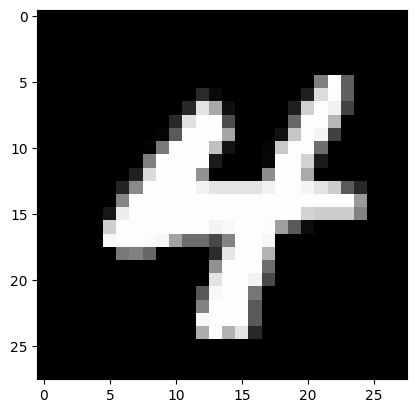

Prediction : 7, Label : 7


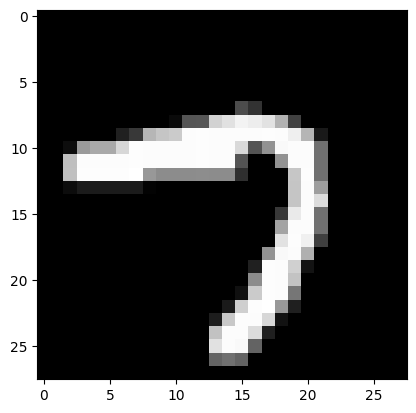

Prediction : 6, Label : 6


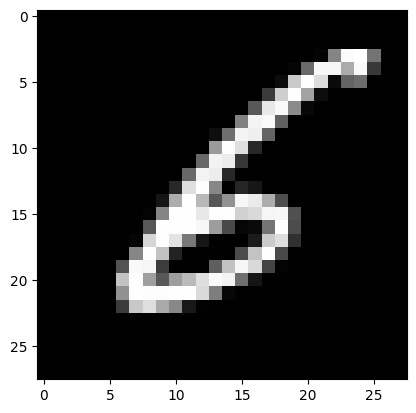

Prediction : 2, Label : 2


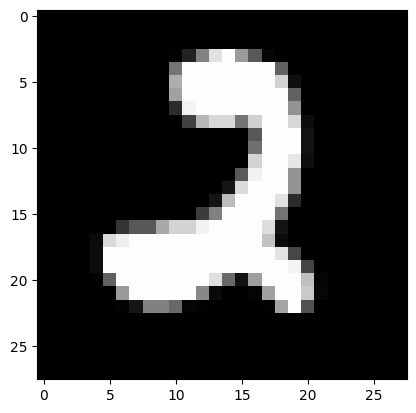

Prediction : 2, Label : 2


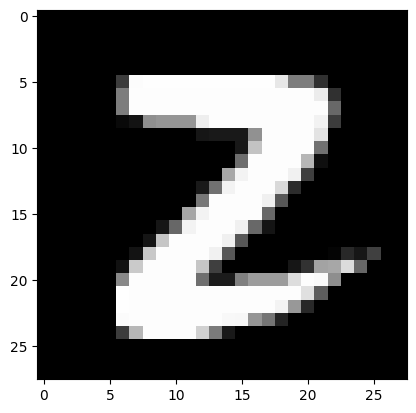

In [20]:
for i in range(5):
    evaluate_model(i,weight1,bias1,weight2,bias2)

In [23]:
test_predictions = predict(X_test,trained_weight1,trained_bias1,trained_weight2,trained_bias2)
print(f"Test Set Accuracy: {calc_accuracy(test_predictions,Y_test,print_result=True)*100}%")

[0 3 2 7 8 7 2 4 9 5 1 5 8 7 3 6 8 9 0 8 4 4 6 3 0 8 2 8 4 0 0 2 4 2 6 0 6
 7 8 9 2 0 0 1 9 9 1 2 4 7 3 4 7 3 3 7 9 0 3 9 1 7 8 9 9 6 8 3 4 3 1 1 3 3
 4 8 2 1 5 3 7 7 5 4 0 1 1 5 2 5 4 8 5 8 6 8 2 9 1 9 1 8 6 0 7 7 5 9 6 7 6
 1 8 0 9 5 0 6 7 3 3 2 0 2 2 6 3 8 8 6 8 5 0 9 3 6 2 6 1 2 6 2 0 4 9 1 7 6
 0 2 9 2 5 3 6 1 7 6 5 2 6 0 6 7 3 4 8 8 7 1 8 2 6 8 6 9 1 9 7 1 7 1 1 1 4
 0 8 2 7 6 9 7 6 1 1 0 9 7 1 1 5 4 2 5 6 9 4 9 8 0 4 1 6 4 2 5 3 9 3 7 6 3
 9 5 0 2 9 9 2 4 2 8 9 3 3 3 4 0 9 7 6 3 2 3 7 2 4 9 3 6 8 7 9 8 2 7 3 4 7
 8 5 2 8 6 6 7 1 7 0 2 7 9 5 0 6 1 2 5 1 4 6 1 4 7 7 2 2 0 2 5 9 7 1 3 1 1
 6 6 7 6 8 1 9 2 9 5 7 0 9 4 4 0 7 5 4 8 4 4 3 4 6 4 9 0 6 1 8 8 3 9 3 1 4
 3 8 9 0 4 3 5 7 3 8 4 8 9 6 2 8 6 6 8 4 3 0 7 7 5 0 2 1 5 7 4 4 5 2 2 6 2
 6 5 9 6 2 4 1 8 2 3 1 6 6 7 4 3 7 2 7 4 9 5 5 2 7 5 9 2 6 3 4 0 0 2 9 9 1
 0 0 6 0 9 7 4 8 6 9 5 0 8 2 6 6 4 6 3 2 3 6 2 5 3 3 9 2 3 3 3 1 5 7 7 8 3
 4 1 3 7 3 5 3 5 6 1 9 9 8 9 7 6 4 0 6 9 9 4 6 1 3 5 0 4 6 3 3 6 3 6 9 1 1
 2 7 8 5 1 7 3 5 8 3 6 3 